# Notebook 1 - Player Tracking

**TFM: Analisis de tenis mediante Computer Vision**

Objetivo: detectar y trackear los dos jugadores en cada frame usando YOLOv8 + ByteTrack, exportar posiciones de pies a `outputs/tracking/player_positions.csv`.

**Requisitos:** `Kernel -> Restart & Run All`  
**Dependencias:** `ultralytics`, `opencv-python`, `torch`, `pandas`, `numpy`, `matplotlib`, `lap`

## Índice

1. Configuración
2. Carga del modelo YOLOv8 + chequeo de hardware
3. Procesamiento del clip
4. Trayectorias sobre el primer frame
5. Exportar CSV

In [1]:
# ── Stdlib ──
import re
import time
import warnings
from pathlib import Path

# ── Numérico / datos ──
import numpy as np
import pandas as pd

# ── Visión artificial ──
import cv2

# ── Deep learning ──
import torch
from ultralytics import YOLO

# ── Visualización ──
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

## 1. Configuracion

Todas las rutas y parametros configurables viven aqui.

In [3]:
# ----- Rutas -----
PROJECT_ROOT = Path.cwd()
DATASET_ROOT = PROJECT_ROOT / "Dataset"
OUTPUTS_ROOT = PROJECT_ROOT / "outputs"
TRACKING_OUT = OUTPUTS_ROOT / "tracking"
TRACKING_OUT.mkdir(parents=True, exist_ok=True)

# ----- Clip de prueba -----
GAME = "game5"
CLIP = "Clip15"
CLIP_DIR = DATASET_ROOT / GAME / CLIP

# ----- Modelo YOLO -----
# imgsz=960: buen compromiso CPU (~1.8x mas rapido que 1280).
# Si aun va lento: baja a 640. Si tienes GPU: sube a 1280.
YOLO_MODEL = "yolov8s.pt"
IMGSZ = 960
PERSON_CLASS_ID = 0
CONF_THRESHOLD = 0.35
IOU_THRESHOLD = 0.5
TRACKER_CFG = "bytetrack.yaml"

# ----- Velocidad: submuestreo de frames -----
# FRAME_STEP=1: todos los frames (recomendado si el clip tarda < 5 min).
# FRAME_STEP=2: 1 de cada 2 (~2x mas rapido, los saltados se interpolan).
FRAME_STEP = 1

# ----- Filtro geometrico -----
# Fracciones de la imagen (0.0-1.0). Calibradas sobre game1/Clip1 (1280x720).
X_BAND_LEFT_FRAC  = 0.15
X_BAND_RIGHT_FRAC = 0.85
Y_TOP_FRAC        = 0.10
Y_BOTTOM_FRAC     = 0.97
MID_LINE_Y_FRAC   = 0.55
MIN_BBOX_AREA     = 1500

# Zonas de exclusion [x_min, y_min, x_max, y_max] en fracciones.
# Excluye detecciones cuyo PUNTO DE PIE caiga dentro.
EXCLUSION_ZONES = [
    [0.14, 0.28, 0.25, 0.48],   # recoge-pelotas / juez izq. de red
    [0.75, 0.28, 0.86, 0.48],   # recoge-pelotas / juez der. de red
    # Jueces de fondo: franja estrecha pegada al borde superior (10-14% Y),
    # solo zona central. Reducida para no tapar al jugador retrasado
    # (cuyo pie cae aprox. al 18-22% Y).
    [0.32, 0.10, 0.68, 0.14],
]

# ----- Salida / visualizacion -----
OUTPUT_CSV = TRACKING_OUT / "player_positions.csv"
SAMPLE_FRAME_IDX = 30

print(f"Proyecto:   {PROJECT_ROOT}")
print(f"Clip:       {CLIP_DIR}")
print(f"Salida CSV: {OUTPUT_CSV}")
print(f"imgsz={IMGSZ} | FRAME_STEP={FRAME_STEP}")
assert CLIP_DIR.exists(), f"No se encuentra el clip: {CLIP_DIR}"


Proyecto:   c:\Users\cosme\Documents\UNAV\TFM\ProyectoTFM
Clip:       c:\Users\cosme\Documents\UNAV\TFM\ProyectoTFM\Dataset\game5\Clip15
Salida CSV: c:\Users\cosme\Documents\UNAV\TFM\ProyectoTFM\outputs\tracking\player_positions.csv
imgsz=960 | FRAME_STEP=1


## 2. Carga del modelo YOLOv8 + chequeo de hardware

Se filtrara unicamente la clase `person`. Se avisa si no hay GPU.

In [4]:
if torch.cuda.is_available():
    DEVICE = "cuda"
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")
else:
    DEVICE = "cpu"
    warnings.warn(
        "No se ha detectado GPU. Continuando en CPU. "
        "Considera reducir IMGSZ o aumentar FRAME_STEP si tarda demasiado.",
        stacklevel=2,
    )
    print("Ejecutando en CPU.")

model = YOLO(YOLO_MODEL)
print(f"Modelo: {YOLO_MODEL} | imgsz={IMGSZ} | clases COCO: {len(model.names)}")
print(f"Clase usada: {PERSON_CLASS_ID} -> {model.names[PERSON_CLASS_ID]}")


Ejecutando en CPU.
Modelo: yolov8s.pt | imgsz=960 | clases COCO: 80
Clase usada: 0 -> person


C:\Users\cosme\AppData\Roaming\Python\Python313\site-packages\IPython\core\interactiveshell.py:3699: UserWarning: No se ha detectado GPU. Continuando en CPU. Considera reducir IMGSZ o aumentar FRAME_STEP si tarda demasiado.
  exec(code_obj, self.user_global_ns, self.user_ns)


## 3. Procesamiento del clip

**Pipeline:**
1. Listar y ordenar frames.
2. **Submuestrear** (1 de cada `FRAME_STEP` frames).
3. YOLOv8 + ByteTrack.
4. **Filtro geometrico**: bandas globales + zonas de exclusion (recogepelotas de red, jueces, arbitro).
5. **Interpolacion lineal** de frames saltados para reconstruir la trayectoria completa.
6. Re-mapeo a etiquetas estables `player_top` / `player_bottom`.

In [5]:
FRAME_RE = re.compile(r"^\d+\.jpg$", re.IGNORECASE)

def list_frames(clip_dir):
    files = [p for p in clip_dir.iterdir() if FRAME_RE.match(p.name)]
    files.sort(key=lambda p: int(p.stem))
    return files

frames = list_frames(CLIP_DIR)
print(f"{len(frames)} frames en {CLIP_DIR.name} | Primero: {frames[0].name} | Ultimo: {frames[-1].name}")

_h0, _w0 = cv2.imread(str(frames[0])).shape[:2]
FRAME_W, FRAME_H = _w0, _h0
print(f"Resolucion: {FRAME_W}x{FRAME_H}")

X_MIN = X_BAND_LEFT_FRAC  * FRAME_W
X_MAX = X_BAND_RIGHT_FRAC * FRAME_W
Y_MIN = Y_TOP_FRAC        * FRAME_H
Y_MAX = Y_BOTTOM_FRAC     * FRAME_H
Y_MID = MID_LINE_Y_FRAC   * FRAME_H

EXCLUSION_ZONES_PX = [
    [zx0*FRAME_W, zy0*FRAME_H, zx1*FRAME_W, zy1*FRAME_H]
    for (zx0, zy0, zx1, zy1) in EXCLUSION_ZONES
]
print(f"Banda X: [{X_MIN:.0f}, {X_MAX:.0f}] | Banda Y: [{Y_MIN:.0f}, {Y_MAX:.0f}] | mid_y={Y_MID:.0f}")
for i, z in enumerate(EXCLUSION_ZONES_PX):
    print(f"  Excl.{i+1}: x=[{z[0]:.0f},{z[2]:.0f}] y=[{z[1]:.0f},{z[3]:.0f}]")


174 frames en Clip15 | Primero: 0000.jpg | Ultimo: 0173.jpg
Resolucion: 1280x720
Banda X: [192, 1088] | Banda Y: [72, 698] | mid_y=396
  Excl.1: x=[179,320] y=[202,346]
  Excl.2: x=[960,1101] y=[202,346]
  Excl.3: x=[410,870] y=[72,101]


In [ ]:
def select_two_players(xyxy, conf, ids):
    foot_x = (xyxy[:, 0] + xyxy[:, 2]) / 2.0
    foot_y = xyxy[:, 3]
    area   = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
    valid = (foot_x >= X_MIN) & (foot_x <= X_MAX) & (foot_y >= Y_MIN) & (foot_y <= Y_MAX)
    for (zx0, zy0, zx1, zy1) in EXCLUSION_ZONES_PX:
        valid &= ~((foot_x >= zx0) & (foot_x <= zx1) & (foot_y >= zy0) & (foot_y <= zy1))
    valid &= (area >= MIN_BBOX_AREA)
    if not valid.any():
        return []
    idxs = np.where(valid)[0]
    selected = []
    top = idxs[foot_y[idxs] < Y_MID]
    if len(top): selected.append(top[np.argmax(area[top])])
    bot = idxs[foot_y[idxs] >= Y_MID]
    if len(bot): selected.append(bot[np.argmax(area[bot])])
    return selected


sampled_frames  = frames[::FRAME_STEP]
sampled_indices = list(range(0, len(frames), FRAME_STEP))
print(f"Frames totales: {len(frames)} | procesados (step={FRAME_STEP}): {len(sampled_frames)}")

records_sampled = []
t0 = time.time()

results_iter = model.track(
    source=[str(p) for p in sampled_frames],
    classes=[PERSON_CLASS_ID],
    conf=CONF_THRESHOLD,
    iou=IOU_THRESHOLD,
    imgsz=IMGSZ,
    tracker=TRACKER_CFG,
    device=DEVICE,
    persist=True,
    stream=True,
    verbose=False,
)

for enum_idx, result in enumerate(results_iter):
    frame_idx = sampled_indices[enum_idx]
    boxes = result.boxes
    if boxes is None or len(boxes) == 0:
        continue
    xyxy = boxes.xyxy.cpu().numpy()
    conf = boxes.conf.cpu().numpy()
    ids  = boxes.id.cpu().numpy().astype(int) if boxes.id is not None else None
    for i in select_two_players(xyxy, conf, ids):
        x1, y1, x2, y2 = xyxy[i]
        records_sampled.append({
            "clip":       f"{GAME}/{CLIP}",
            "frame":      frame_idx,
            "player_id":  int(ids[i]) if ids is not None else int(i),
            "foot_x":     float((x1 + x2) / 2),
            "foot_y":     float(y2),
            "bbox_x1":    float(x1), "bbox_y1": float(y1),
            "bbox_x2":    float(x2), "bbox_y2": float(y2),
            "confidence": float(conf[i]),
        })

elapsed = time.time() - t0
print(f"Inferencia: {elapsed:.1f}s  ({elapsed/len(sampled_frames):.2f}s/frame)")
df_sampled = pd.DataFrame.from_records(records_sampled)
print(f"Detecciones: {len(df_sampled)} | player_ids: {sorted(df_sampled['player_id'].unique())}")
df_sampled.head()

Frames totales: 174 | procesados (step=1): 174


In [ ]:
# Interpolacion lineal de frames saltados
def interpolate_players(df_sampled, total_frames):
    num_cols = ["foot_x", "foot_y", "bbox_x1", "bbox_y1", "bbox_x2", "bbox_y2", "confidence"]
    parts = []
    for pid in df_sampled["player_id"].unique():
        sub = (df_sampled[df_sampled["player_id"] == pid]
               .set_index("frame")
               .reindex(range(total_frames)))
        sub["clip"] = sub["clip"].ffill().bfill()
        sub[num_cols] = sub[num_cols].interpolate(method="linear").ffill().bfill()
        sub["player_id"] = pid
        parts.append(sub.reset_index().rename(columns={"index": "frame"}))
    return (pd.concat(parts, ignore_index=True)
            .sort_values(["frame", "player_id"]).reset_index(drop=True))

df_players = interpolate_players(df_sampled, len(frames))
n_interp = len(df_players) - len(df_sampled)
print(f"Tras interpolacion: {len(df_players)} filas ({len(df_sampled)} detectadas + {n_interp} interpoladas)")
display(df_players.head())

# Re-mapeo a etiquetas estables player_top / player_bottom
df_players["half"] = np.where(df_players["foot_y"] < Y_MID, "top", "bottom")
dominant_half = df_players.groupby("player_id")["half"].agg(lambda s: s.mode().iloc[0])
id_to_label   = {pid: f"player_{h}" for pid, h in dominant_half.items()}
df_players["player_label"] = df_players["player_id"].map(id_to_label)

df_players = (
    df_players
    .sort_values(["frame", "player_label", "confidence"], ascending=[True, True, False])
    .drop_duplicates(subset=["frame", "player_label"], keep="first")
    .reset_index(drop=True)
)
print(df_players["player_label"].value_counts().to_string())
df_players.head()

Tras interpolacion: 414 filas (414 detectadas + 0 interpoladas)


,frame,clip,player_id,foot_x,foot_y,bbox_x1,bbox_y1,bbox_x2,bbox_y2,confidence
0,0,game1/Clip1,1,566.261047,548.841553,529.358215,391.987366,603.163879,548.841553,0.881487
1,0,game1/Clip1,2,783.689575,157.894043,760.873047,102.656708,806.506165,157.894043,0.818488
2,1,game1/Clip1,1,565.585938,548.736877,528.727173,391.975769,602.444763,548.736877,0.868475
3,1,game1/Clip1,2,783.696533,157.949646,760.477051,101.714828,806.915955,157.949646,0.819036
4,2,game1/Clip1,1,563.739746,547.907104,526.326965,388.300598,601.152588,547.907104,0.858075


### Frame de ejemplo con bboxes y zonas de filtrado

Zonas rojas = exclusion | linea cyan = separacion top/bottom | lineas blancas = banda global.

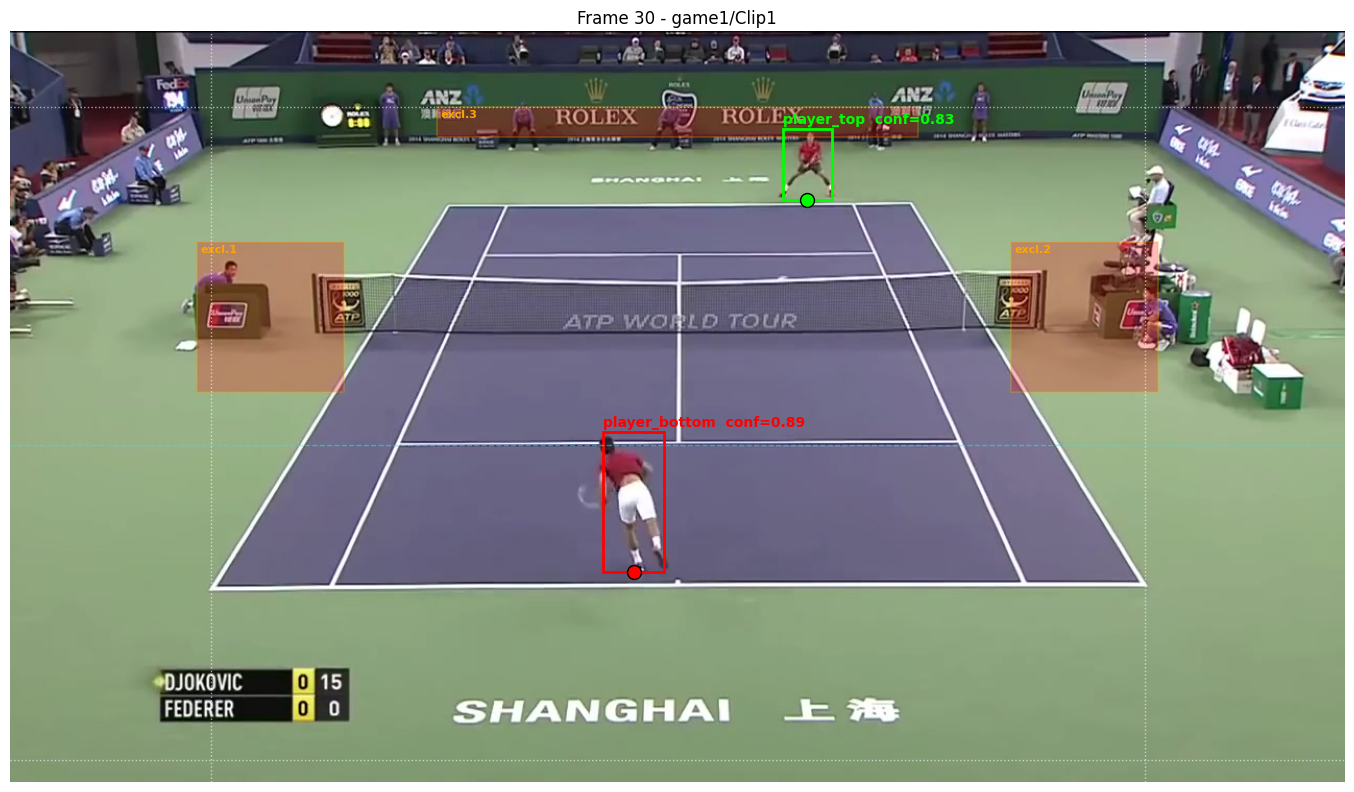

In [ ]:
sample_idx = min(SAMPLE_FRAME_IDX, len(frames) - 1)
img = cv2.cvtColor(cv2.imread(str(frames[sample_idx])), cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(img)

ax.axvline(X_MIN, color="white", ls=":", alpha=0.6, lw=1)
ax.axvline(X_MAX, color="white", ls=":", alpha=0.6, lw=1)
ax.axhline(Y_MIN, color="white", ls=":", alpha=0.6, lw=1)
ax.axhline(Y_MAX, color="white", ls=":", alpha=0.6, lw=1)
ax.axhline(Y_MID, color="cyan",  ls="--", alpha=0.5, lw=1)

for i, (zx0, zy0, zx1, zy1) in enumerate(EXCLUSION_ZONES_PX):
    ax.add_patch(mpatches.Rectangle(
        (zx0, zy0), zx1-zx0, zy1-zy0,
        lw=1.5, edgecolor="orange", facecolor="red", alpha=0.25))
    ax.text(zx0+3, zy0+10, f"excl.{i+1}", color="orange", fontsize=8, weight="bold")

label_colors = {"player_top": "lime", "player_bottom": "red"}
sample_rows = df_players[df_players["frame"] == sample_idx]
for _, row in sample_rows.iterrows():
    color = label_colors.get(row["player_label"], "yellow")
    w, h = row["bbox_x2"]-row["bbox_x1"], row["bbox_y2"]-row["bbox_y1"]
    ax.add_patch(mpatches.Rectangle((row["bbox_x1"], row["bbox_y1"]), w, h,
                                     fill=False, edgecolor=color, lw=2))
    ax.text(row["bbox_x1"], row["bbox_y1"]-6,
            f"{row['player_label']}  conf={row['confidence']:.2f}",
            color=color, fontsize=10, weight="bold")
    ax.plot(row["foot_x"], row["foot_y"], "o", color=color, ms=10, mec="black")

ax.set_title(f"Frame {sample_idx} - {GAME}/{CLIP}")
ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Trayectorias sobre el primer frame

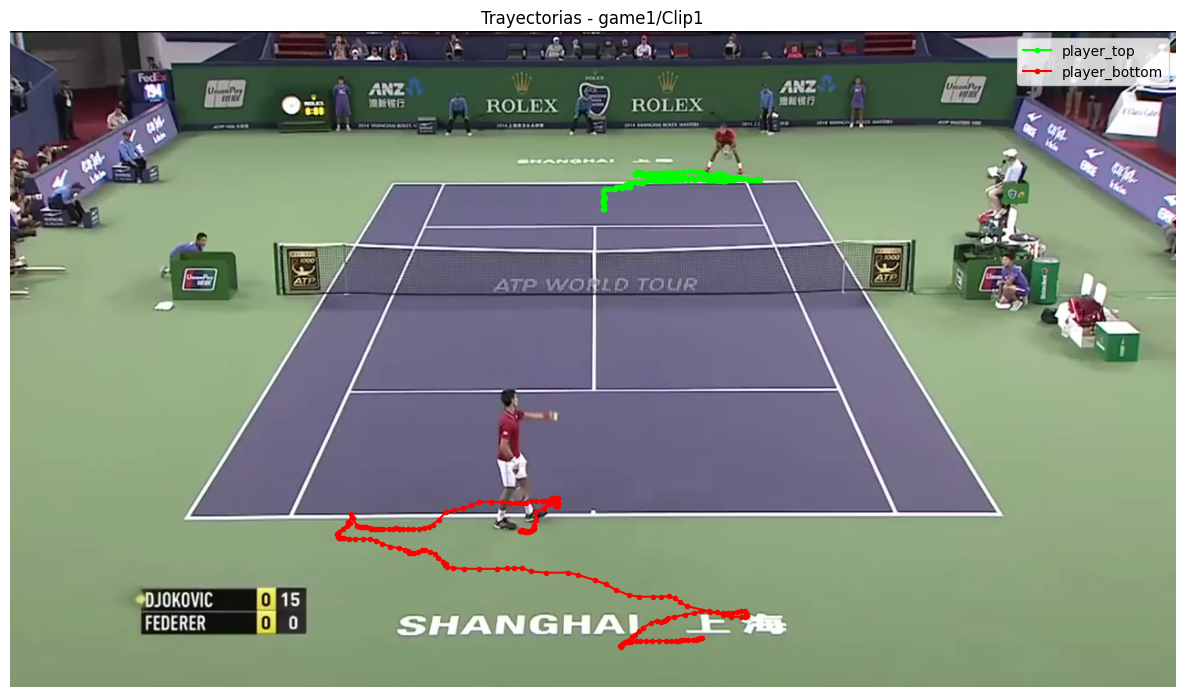

In [ ]:
first_img = cv2.cvtColor(cv2.imread(str(frames[0])), cv2.COLOR_BGR2RGB)
fig, ax = plt.subplots(figsize=(12, 7))
ax.imshow(first_img)
for label, color in [("player_top", "lime"), ("player_bottom", "red")]:
    sub = df_players[df_players["player_label"] == label].sort_values("frame")
    if len(sub):
        ax.plot(sub["foot_x"], sub["foot_y"], "-o", ms=3, lw=1.5, color=color, label=label)
ax.set_title(f"Trayectorias - {GAME}/{CLIP}")
ax.axis("off")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 5. Exportar CSV

In [9]:
df_out = df_players[[
    "clip", "frame", "player_id", "player_label",
    "foot_x", "foot_y",
    "bbox_x1", "bbox_y1", "bbox_x2", "bbox_y2",
    "confidence",
]]
df_out.to_csv(OUTPUT_CSV, index=False)
print(f"Guardado {len(df_out)} filas en {OUTPUT_CSV}")
df_out.tail()


Guardado 414 filas en c:\Users\cosme\Documents\UNAV\TFM\ProyectoTFM\outputs\tracking\player_positions.csv


,clip,frame,player_id,player_label,foot_x,foot_y,bbox_x1,bbox_y1,bbox_x2,bbox_y2,confidence
409,game1/Clip1,204,2,player_top,651.798218,194.369141,635.509888,106.589867,668.086487,194.369141,0.776838
410,game1/Clip1,205,1,player_bottom,757.147095,666.170532,717.960510,489.570404,796.333740,666.170532,0.880363
411,game1/Clip1,205,2,player_top,651.646362,194.434250,635.726929,108.019394,667.565796,194.434250,0.754741
412,game1/Clip1,206,1,player_bottom,759.003296,665.381287,720.073120,488.954163,797.933533,665.381287,0.874502
413,game1/Clip1,206,2,player_top,651.002014,194.584000,635.189758,108.219223,666.814270,194.584000,0.759628
